In [87]:
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
# 데이터 읽기
monthly_data = pd.read_csv('monthly_data.csv')

In [89]:
monthly_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   type           96 non-null     str    
 1   contract_ym    96 non-null     str    
 2   deal_count     96 non-null     int64  
 3   amount_median  96 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.1 KB


### 월별 거래량 분석

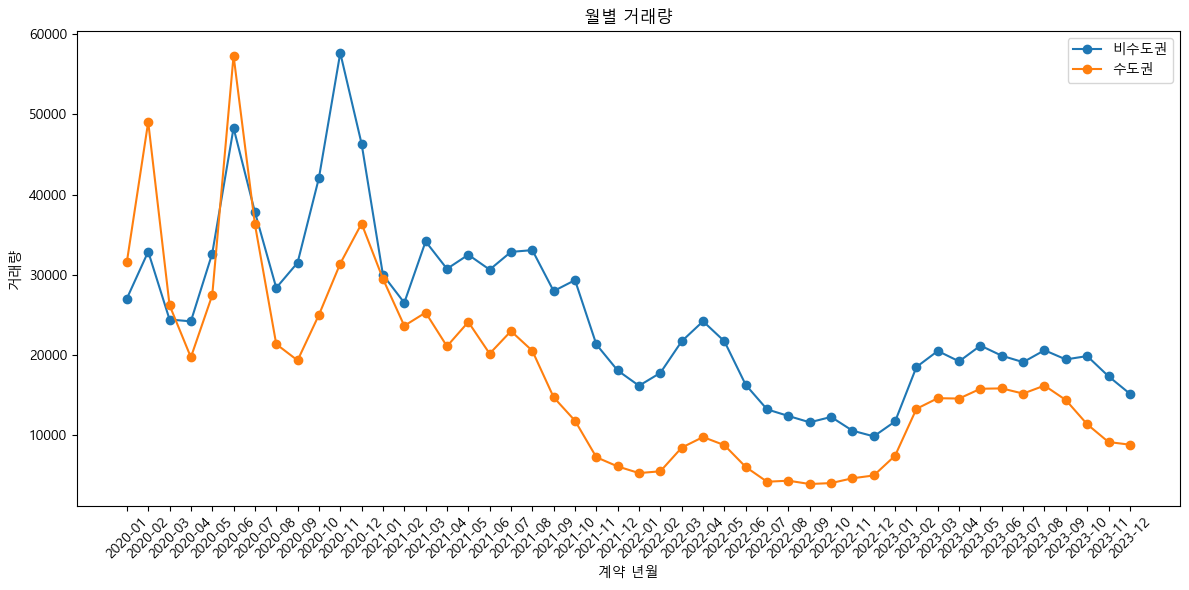

In [ ]:
# 유형별 월별 거래량 그래프 그리기
plt.figure(figsize=(12, 6)) # 그래프 크기 설정

for t in monthly_data['type'].unique(): # 유형별로 그래프 그리기
    subset = monthly_data[monthly_data['type'] == t]
    subset = subset.sort_values('contract_ym')

    plt.plot(subset['contract_ym'], subset['deal_count'], marker='o', label=t)

plt.legend() # 범례 표시
plt.xticks(rotation=45) # x축 레이블 회전
plt.title('월별 거래량') # 그래프 제목
plt.xlabel('계약 년월') # x축 레이블
plt.ylabel('거래량') # y축 레이블

plt.tight_layout() # 레이아웃 조정
plt.show() # 그래프 표시

In [91]:
# 사건 시점
events = { # 사건 시점과 레이블 정의
    '2022-04': '제도 시행 예고',
    '2022-05': '제도 시행'
}

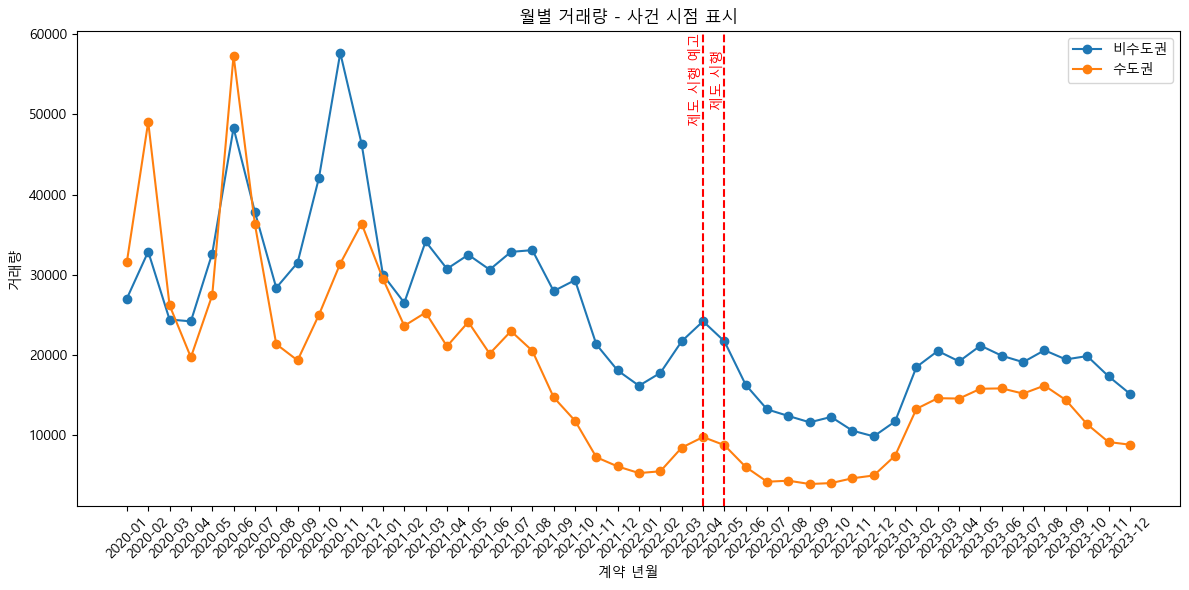

In [ ]:
# 사건 시점 표시한 거래량 그래프 그리기
plt.figure(figsize=(12, 6))
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t]
    subset = subset.sort_values('contract_ym')

    plt.plot(subset['contract_ym'], subset['deal_count'], marker='o', label=t)

for event_date, event_label in events.items(): # 사건 시점마다 수직선과 레이블 추가
    plt.axvline(x=event_date, color='red', linestyle='--')
    plt.text(event_date, plt.ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

plt.legend()
plt.xticks(rotation=45)
plt.title('월별 거래량 - 사건 시점 표시')
plt.xlabel('계약 년월')
plt.ylabel('거래량')
plt.tight_layout()
plt.show()

In [93]:
# 기간 조정하기 - 2022년 1월부터 12월까지로 범위 좁히기
monthly_data = monthly_data[(monthly_data['contract_ym'] >= '2022-01') & (monthly_data['contract_ym'] <= '2022-12')]

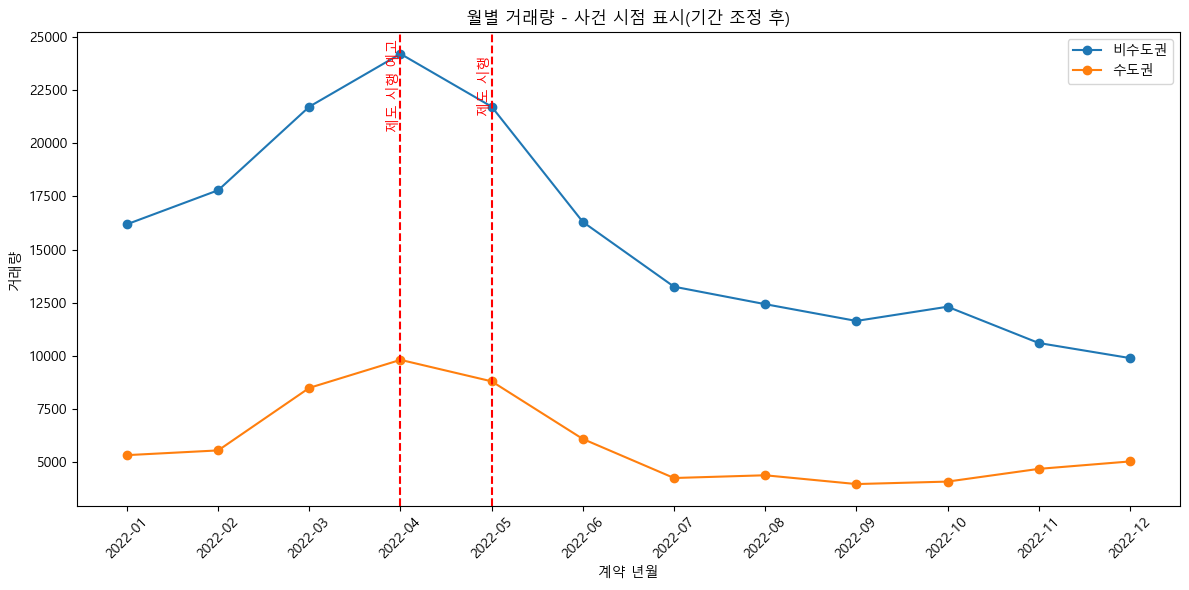

In [ ]:
# 사건 시점 표시한 거래량 그래프 그리기(기간 조정 후)
plt.figure(figsize=(12, 6))
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t]
    subset = subset.sort_values('contract_ym')

    plt.plot(subset['contract_ym'], subset['deal_count'], marker='o', label=t)

for event_date, event_label in events.items():
    plt.axvline(x=event_date, color='red', linestyle='--')
    plt.text(event_date, plt.ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

plt.legend()
plt.xticks(rotation=45)
plt.title('월별 거래량 - 사건 시점 표시(기간 조정 후)')
plt.xlabel('계약 년월')
plt.ylabel('거래량')
plt.tight_layout()
plt.show()

In [95]:
# 거래량 지수화 - 2022년 1월 거래량을 100으로 기준 잡기
monthly_data['deal_count_index'] = monthly_data.groupby('type')['deal_count'].transform(lambda x: x / x.iloc[0] * 100)

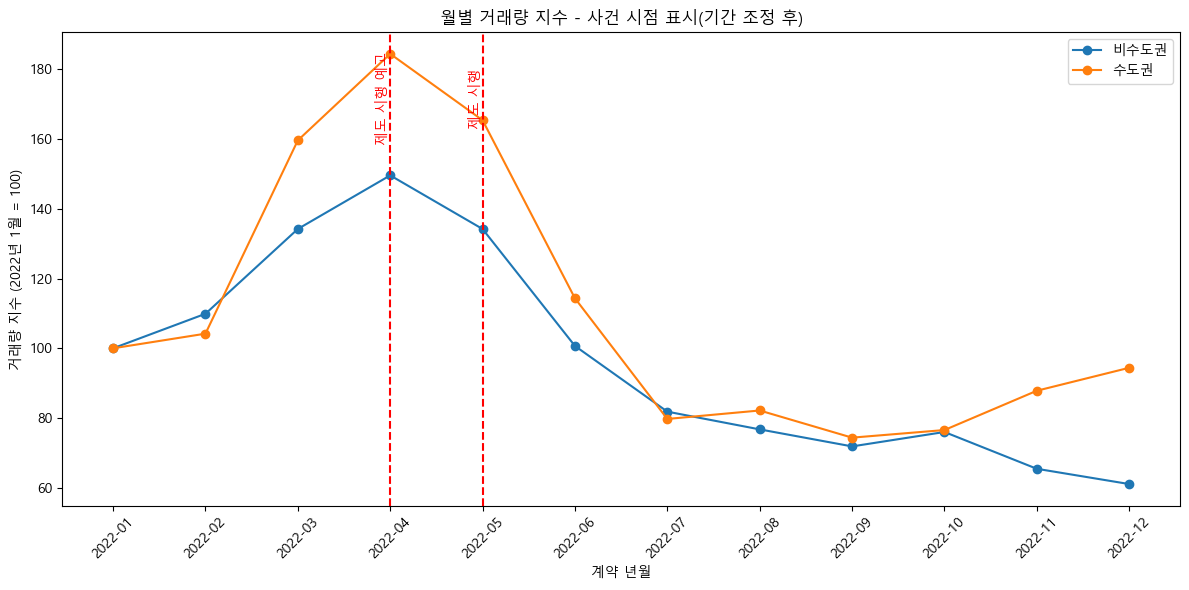

In [ ]:
# 사건 시점 표시한 거래량 지수 그래프 그리기(기간 조정 후)
plt.figure(figsize=(12, 6))
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t]
    subset = subset.sort_values('contract_ym')

    plt.plot(subset['contract_ym'], subset['deal_count_index'], marker='o', label=t) # 거래량 대신 거래량 지수로 그래프 그리기

for event_date, event_label in events.items():
    plt.axvline(x=event_date, color='red', linestyle='--')
    plt.text(event_date, plt.ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

plt.legend()
plt.xticks(rotation=45)
plt.title('월별 거래량 지수 - 사건 시점 표시(기간 조정 후)')
plt.xlabel('계약 년월')
plt.ylabel('거래량 지수 (2022년 1월 = 100)')
plt.tight_layout()
plt.savefig('monthly_deal_count_index.png', dpi=300, bbox_inches='tight') # 그래프 저장
plt.show()

### 월별 거래금액(중위값) 분석

In [97]:
# 거래금액 지수화 - 2022년 1월 거래금액 중앙값을 100으로 기준 잡기
monthly_data['amount_median_index'] = monthly_data.groupby('type')['amount_median'].transform(lambda x: x / x.iloc[0] * 100)

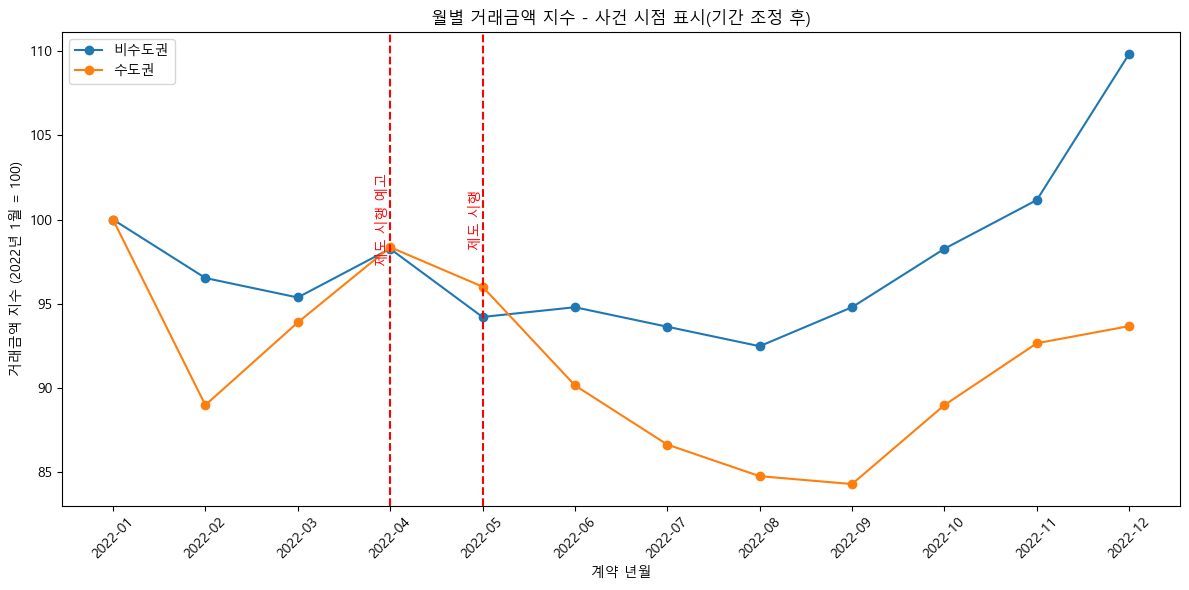

In [ ]:
# 사건 시점 표시한 거래금액(중위값) 지수 그래프 그리기(기간 조정 후)
plt.figure(figsize=(12, 6))
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t]
    subset = subset.sort_values('contract_ym')

    plt.plot(subset['contract_ym'], subset['amount_median_index'], marker='o', label=t) # 거래금액 지수로 그래프 그리기

for event_date, event_label in events.items():
    plt.axvline(x=event_date, color='red', linestyle='--')
    plt.text(event_date, plt.ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

plt.legend()
plt.xticks(rotation=45)
plt.title('월별 거래금액 지수 - 사건 시점 표시(기간 조정 후)')
plt.xlabel('계약 년월')
plt.ylabel('거래금액 지수 (2022년 1월 = 100)')
plt.tight_layout()
plt.savefig('monthly_amount_median_index.png', dpi=300, bbox_inches='tight') # 그래프 저장
plt.show()

### 금리 추가하기

In [173]:
# 금리 데이터 읽기
interest_rate_data = pd.read_csv('source_data/기준금리.csv')

interest_rate_data.head() # 금리 데이터 확인

,변경일자,기준금리
0,2025년 05월 29일,2.50
1,2025년 02월 25일,2.75
2,2024년 11월 28일,3.00
3,2024년 10월 11일,3.25
4,2023년 01월 13일,3.50


In [174]:
# 칼럼명 변경
interest_rate_data.rename(columns={'변경일자': 'event_date'}, inplace=True)
interest_rate_data.rename(columns={'기준금리': 'interest_rate'}, inplace=True)

In [175]:
# 금리 날짜를 datetime 형식으로 변환
interest_rate_data['event_date'] = pd.to_datetime(interest_rate_data['event_date'], format='%Y년 %m월 %d일')

interest_rate_data.sort_values('event_date', inplace=True) # 날짜 기준으로 정렬
interest_rate_data['date_ym'] = interest_rate_data['event_date'].dt.to_period('M').astype(str) # 월별로 변환

# 2022년 1월부터 12월까지의 데이터로 범위 좁히기
interest_rate_data = interest_rate_data[(interest_rate_data['date_ym'] >= '2022-01') & (interest_rate_data['date_ym'] <= '2022-12')]

In [ ]:
# 금리 데이터 확인
interest_rate_data

,event_date,interest_rate,date_ym
11,2022-01-14,1.25,2022-01
10,2022-04-14,1.50,2022-04
9,2022-05-26,1.75,2022-05
8,2022-07-13,2.25,2022-07
7,2022-08-25,2.50,2022-08
6,2022-10-12,3.00,2022-10
5,2022-11-24,3.25,2022-11


In [177]:
# 2022년 12월 데이터 추가하기
new_row = {'event_date': pd.to_datetime('2022-12-31'), 'interest_rate': 3.25, 'date_ym': '2022-12'} # 2022년 12월 데이터 정의
interest_rate_data = pd.concat([interest_rate_data, pd.DataFrame([new_row])], ignore_index=True) # 데이터프레임에 새로운 행 추가

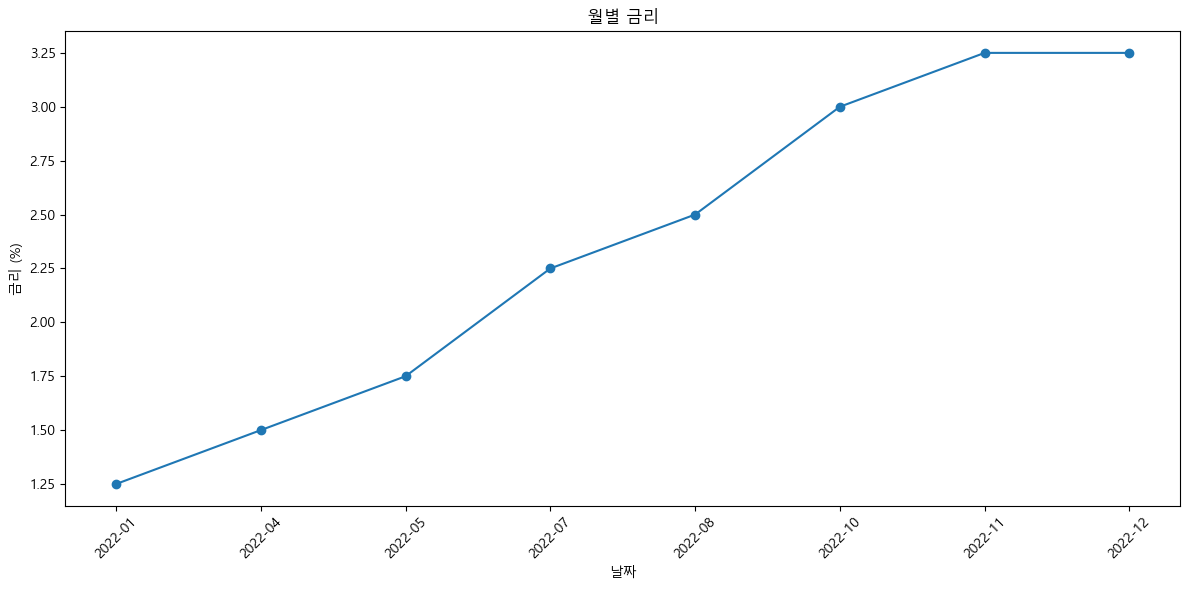

In [179]:
# 월별 금리 그래프 그리기
plt.figure(figsize=(12, 6)) # 그래프 크기 설정
plt.plot(interest_rate_data['date_ym'], interest_rate_data['interest_rate'], marker='o') # 금리 그래프 그리기
plt.xticks(rotation=45) # x축 레이블 회전
plt.title('월별 금리') # 그래프 제목
plt.xlabel('날짜') # x축 레이블
plt.ylabel('금리 (%)') # y축 레이블
plt.tight_layout() # 레이아웃 조정
plt.show() # 그래프 표시

### 거래량, 거래금액에 금리 추가하기

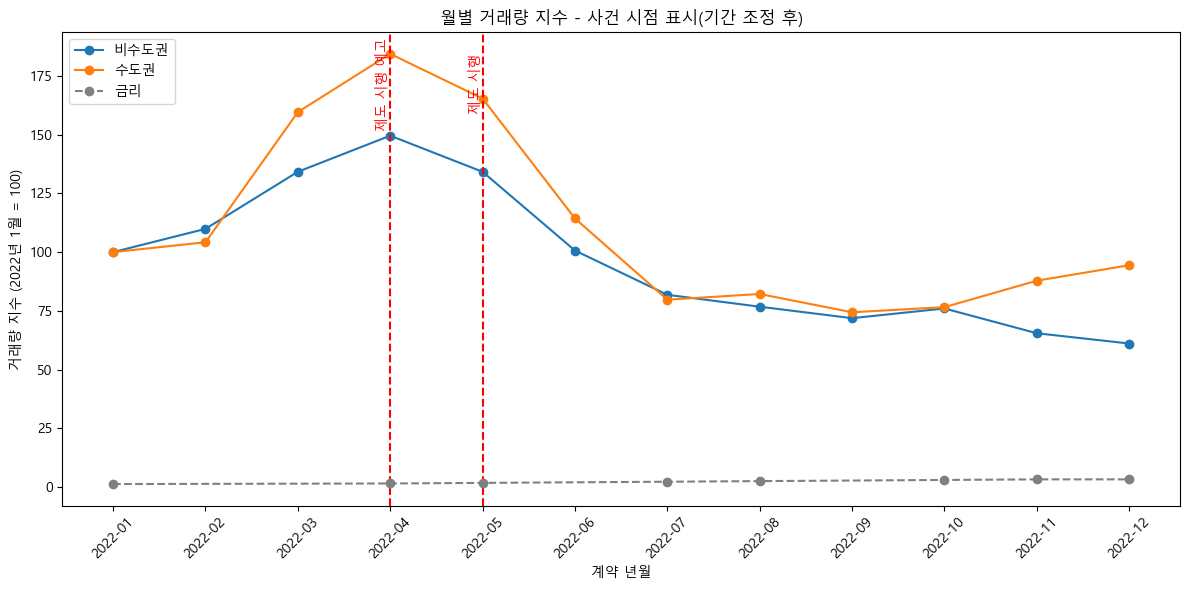

In [ ]:
# 거래량 지수에 금리 추가해서 그래프 그리기
plt.figure(figsize=(12, 6))
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t]
    subset = subset.sort_values('contract_ym')

    plt.plot(subset['contract_ym'], subset['deal_count_index'], marker='o', label=t)

for event_date, event_label in events.items():
    plt.axvline(x=event_date, color='red', linestyle='--')
    plt.text(event_date, plt.ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

plt.plot(interest_rate_data['date_ym'], interest_rate_data['interest_rate'], marker='o', label='금리', color='gray', linestyle='--') # 금리 그래프 추가

plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.title('월별 거래량 지수 - 사건 시점 표시(기간 조정 후)')
plt.xlabel('계약 년월')
plt.ylabel('거래량 지수 (2022년 1월 = 100)')
plt.tight_layout()
plt.show()

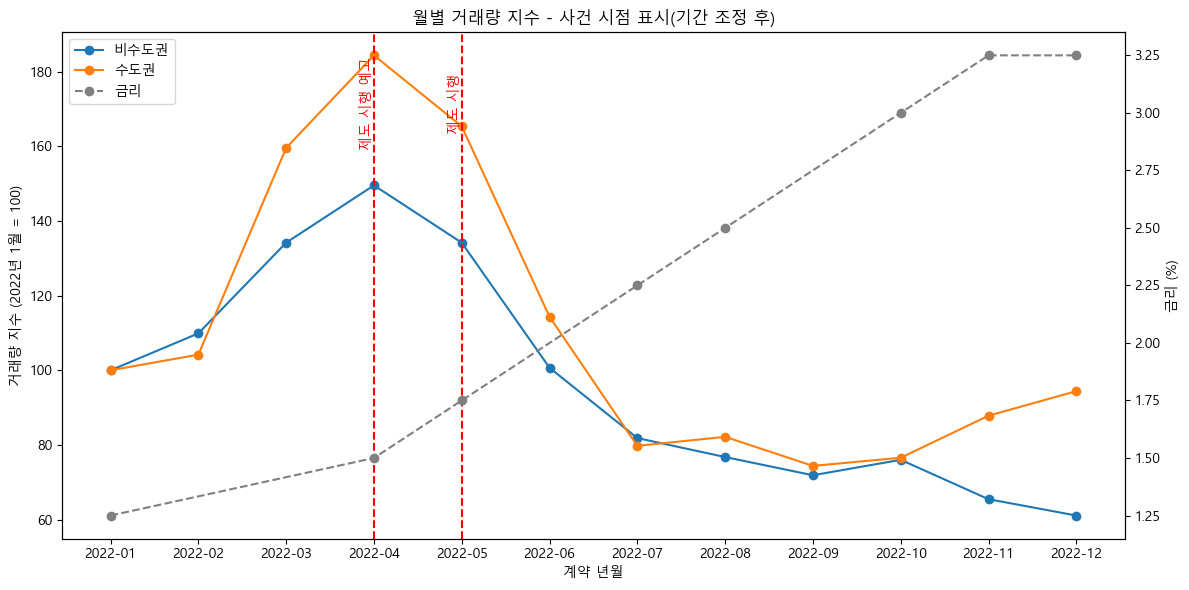

In [191]:
# 거래량 지수에 금리 추가해서 그래프 그리기 - 금리는 보조축으로 표시하기
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. 거래량 지수 (좌측 축)
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t].sort_values('contract_ym')
    ax1.plot(subset['contract_ym'], subset['deal_count_index'], marker='o', label=t)

ax1.set_ylabel('거래량 지수 (2022년 1월 = 100)')

# 2. 이벤트 라인
for event_date, event_label in events.items():
    ax1.axvline(x=event_date, color='red', linestyle='--')
    ax1.text(event_date, ax1.get_ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

# 3. 금리 (우측 축)
ax2 = ax1.twinx()

ax2.plot(interest_rate_data['date_ym'], interest_rate_data['interest_rate'], marker='o', linestyle='--', color='gray', label='금리')

ax2.set_ylabel('금리 (%)')

# 4. 범례 합치기 (중요)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# 5. 기타 설정
ax1.set_title('월별 거래량 지수 - 사건 시점 표시(기간 조정 후)')
ax1.set_xlabel('계약 년월')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('monthly_deal_count_index_with_interest_rate.png', dpi=300, bbox_inches='tight') # 그래프 저장
plt.show()

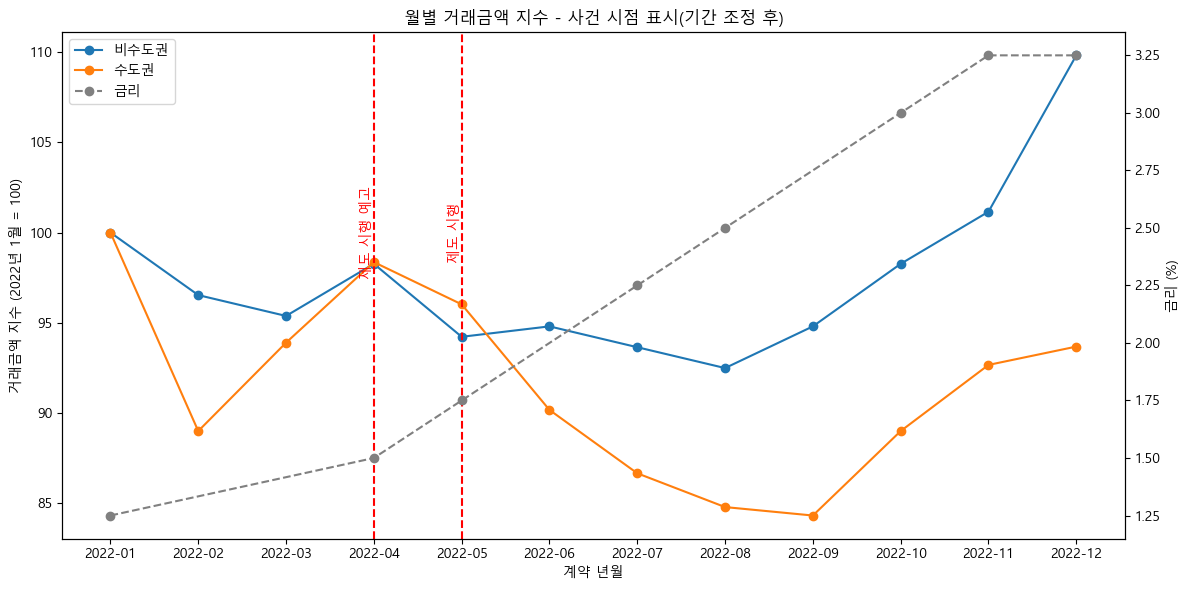

In [193]:
# 거래금액 지수에 금리 추가해서 그래프 그리기 - 금리는 보조축으로 표시하기
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. 거래량 지수 (좌측 축)
for t in monthly_data['type'].unique():
    subset = monthly_data[monthly_data['type'] == t].sort_values('contract_ym')
    ax1.plot(subset['contract_ym'], subset['amount_median_index'], marker='o', label=t)

ax1.set_ylabel('거래금액 지수 (2022년 1월 = 100)')

# 2. 이벤트 라인
for event_date, event_label in events.items():
    ax1.axvline(x=event_date, color='red', linestyle='--')
    ax1.text(event_date, ax1.get_ylim()[1]*0.9, event_label, rotation=90, color='red', ha='right', va='center')

# 3. 금리 (우측 축)
ax2 = ax1.twinx()

ax2.plot(interest_rate_data['date_ym'], interest_rate_data['interest_rate'], marker='o', linestyle='--', color='gray', label='금리')

ax2.set_ylabel('금리 (%)')

# 4. 범례 합치기 (중요)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# 5. 기타 설정
ax1.set_title('월별 거래금액 지수 - 사건 시점 표시(기간 조정 후)')
ax1.set_xlabel('계약 년월')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('monthly_amount_median_index_with_interest_rate.png', dpi=300, bbox_inches='tight') # 그래프 저장
plt.show()